In [98]:
from init_env import cfg
from dataset import load_splits, load_datasets
from models import load_model_and_history, WeightedEnsemble, predict_with_threshold
from gradcam import *

import os
import json
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [4]:
# Extract configuration settings
DATA_PATH = cfg["paths"]["data_path"]
MODEL_PATH = cfg["paths"]["model_path"]
IMG_SIZE = tuple(cfg["img_size"])

# Load datasets
_, _, test_df = load_splits(os.path.join(DATA_PATH, "splits"))

IMG_SIZE = tuple(cfg["img_size"])
labels = cfg["labels"]
mappings = {v: k for k, v in labels.items()}

# Extract model data
with open(os.path.join(MODEL_PATH, "ensemble_metadata.json"), "r") as f:
    model_data = json.load(f)

with open(os.path.join(MODEL_PATH, "best_threshold.json"), "r") as f:
    best_threshold = json.load(f)

file_paths = model_data["file_paths"]
ensemble_weights = np.array(model_data["weights"])
ensemble_models = [load_model_and_history(os.path.join(MODEL_PATH), file_path)[0] for file_path in file_paths]

# Initialise ensemble
ensemble_model = WeightedEnsemble(ensemble_models, ensemble_weights)

# Define the grouping mapping
ethnicity_group_map = {
    "chinese": "Asian",
    "vietnamese": "Asian",
    "uk": "European",
    "portuguese": "European",
    "us": "US",
    "saudi": "Middle Eastern"
}

# Apply the mapping
test_df["ethnicity_grouped"] = test_df["ethnicity"].map(ethnicity_group_map)

### Grad-CAM for US subgroup

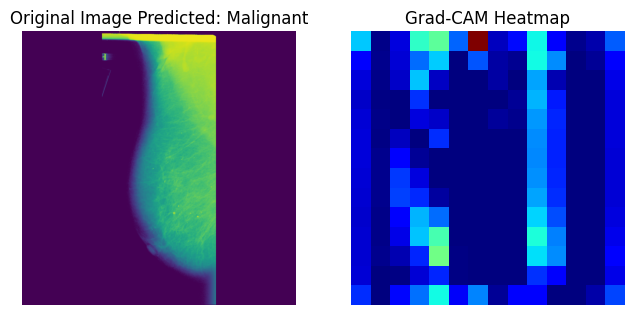

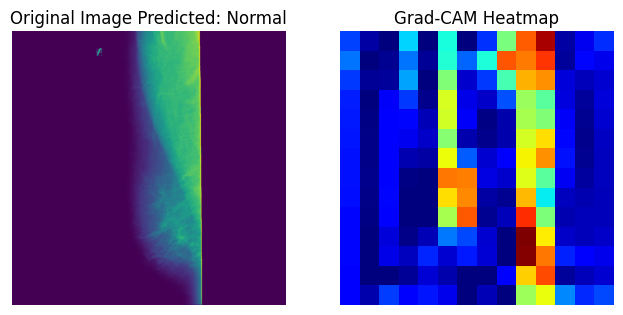

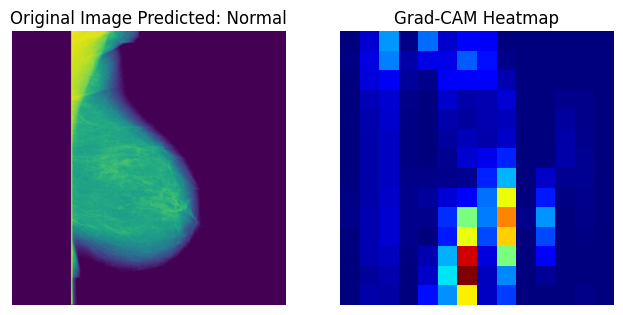

### Grad-CAM for European subgroup

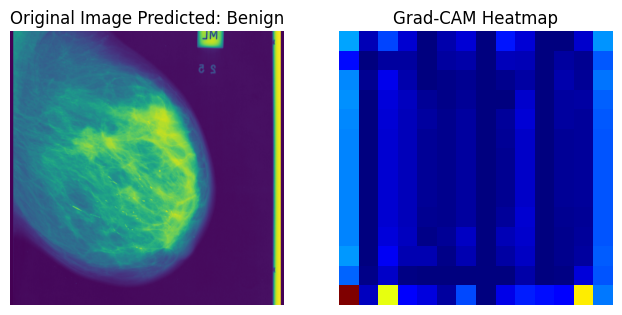

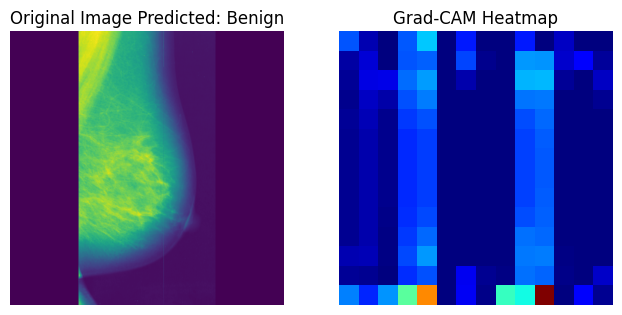

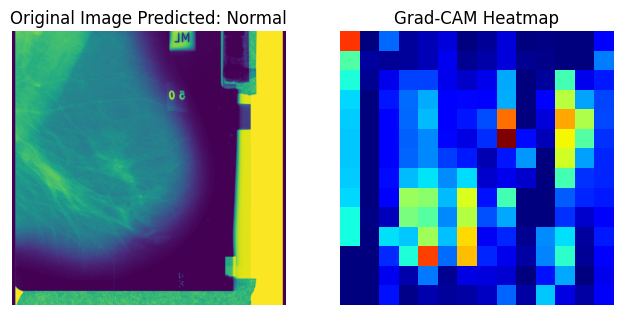

### Grad-CAM for Asian subgroup

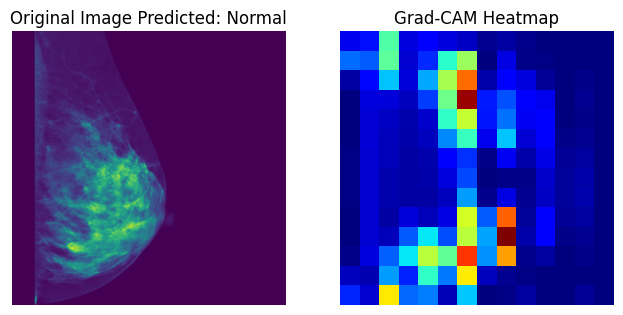

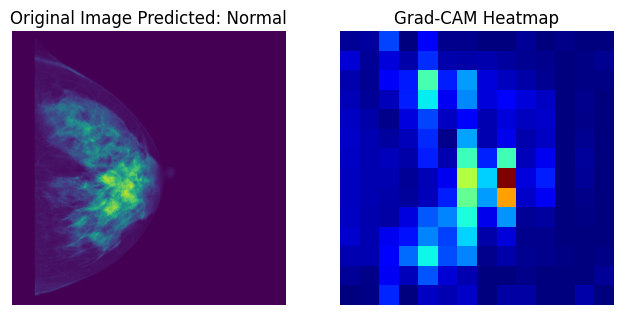

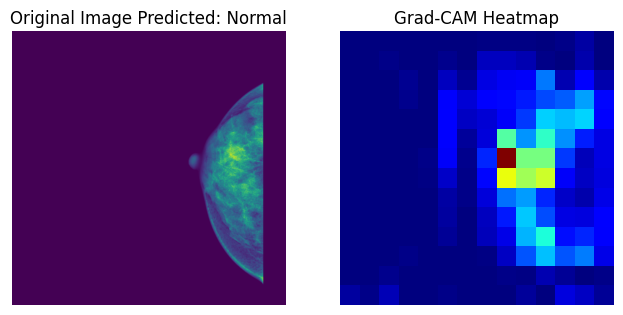

### Grad-CAM for Middle Eastern subgroup

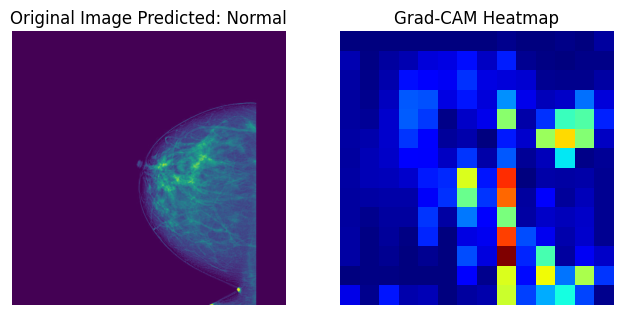

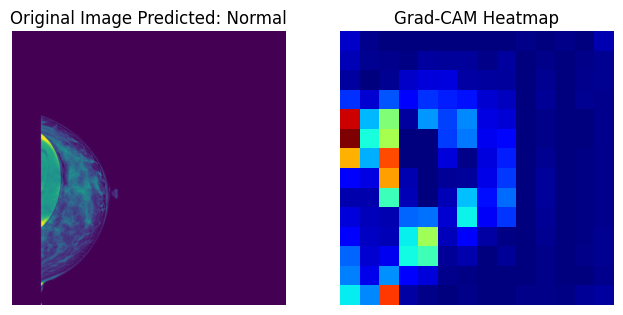

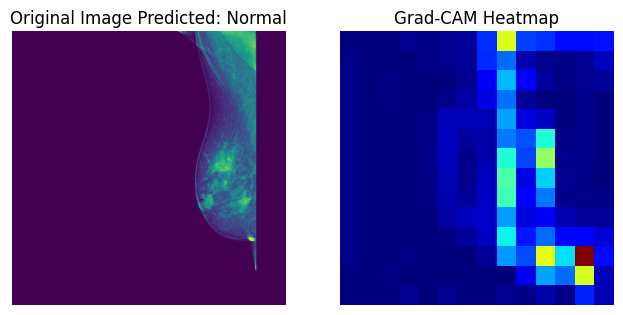

In [103]:
subgroup = test_df["ethnicity_grouped"].unique()
true_label = labels["malignant"]

for sg in subgroup:
    # Filter test images for this subgroup
    sg_df = test_df[test_df["ethnicity_grouped"] == sg]
    display(Markdown(f"### Grad-CAM for {sg} subgroup"))

    for i in range(3):
        # Select first malignant case
        sample_row = sg_df[sg_df["label_int"] == true_label].iloc[i]
        img_path = sample_row["processed_path"]
        
        # Load image
        image = Image.open(img_path)
        
        # Preprocess
        input_tensor, orig_img = preprocess(image, IMG_SIZE)

        # Predict using ensemble
        y_prob = ensemble_model.predict(input_tensor)
        y_pred = predict_with_threshold(y_prob, true_label, best_threshold)[0]

        # Convert to grayscale and then back to RGB for overlay
        image_gray = ImageOps.grayscale(image)
        orig_img_gray = np.array(image_gray.convert("RGB"))
        
        # Generate Grad-CAM
        cam = get_gradcam_ensemble(input_tensor, ensemble_model)
    
        overlay = overlay_cam(orig_img, cam)
        
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.title(f"Original Image Predicted: {mappings[y_pred].capitalize()}")
        plt.imshow(image)
        plt.axis("off")
        
        plt.subplot(1, 3, 2)
        plt.title("Grad-CAM Heatmap")
        plt.imshow(cam, cmap="jet")
        plt.axis("off")
        
        plt.show()